In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

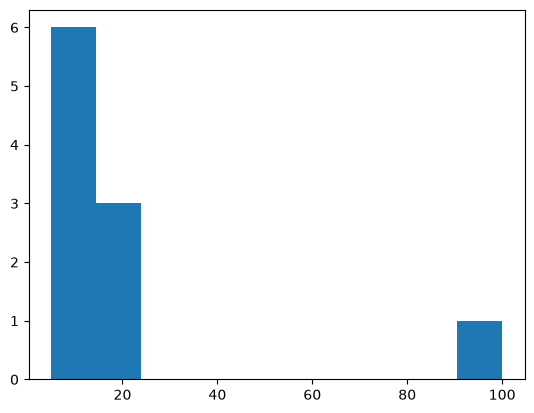

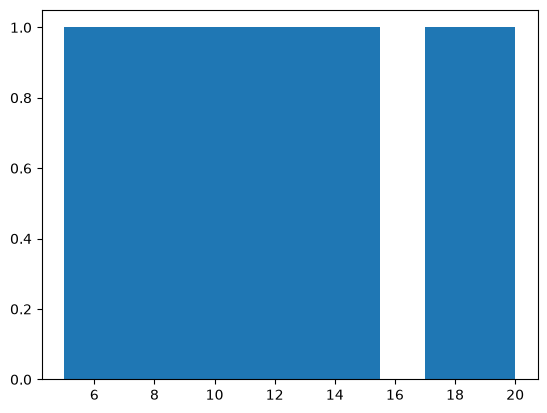

In [21]:
data = [5, 7, 8, 10, 12, 13, 15, 18, 20, 100]
plt.hist(data)
plt.show()
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_data = [x for x in data if lower <= x <= upper]
plt.hist(clean_data)
plt.show()

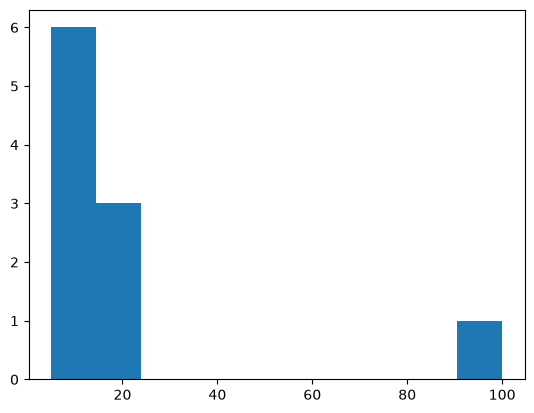

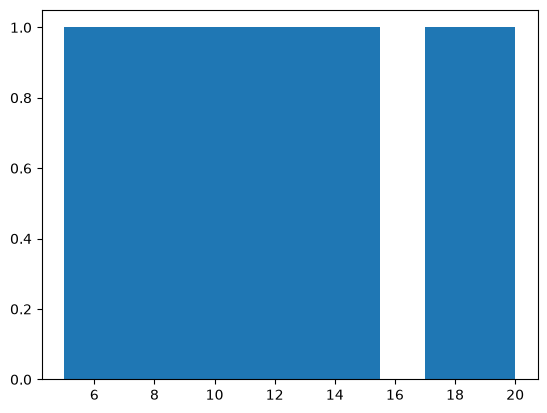

In [24]:
df = pd.DataFrame({'Data':data})
plt.hist(df['Data'])
plt.show()
q1 = df['Data'].quantile(0.25)
q3 = df['Data'].quantile(0.75)
IQR=q3-q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
df_cleaned = df[(df['Data']>=lower) & (df['Data']<=upper)]
plt.hist(df_cleaned)
plt.show()

In [25]:
df["data_capped"]= df['Data'].clip(lower,upper)
df

,Data,data_capped
0,5,5.000
1,7,7.000
2,8,8.000
3,10,10.000
4,12,12.000
5,13,13.000
6,15,15.000
7,18,18.000
8,20,20.000
9,100,30.375


In [32]:
import pandas as pd

df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35],
    "Salary": [50000, 60000, 70000],
    "City": ["Chennai", "Delhi", "Mumbai"]
})
df

,Name,Age,Salary,City
0,Alice,25,50000,Chennai
1,Bob,30,60000,Delhi
2,Charlie,35,70000,Mumbai


In [41]:
df_cleaned = df.copy()
df_ints = df.select_dtypes(include='number')
for i in df_ints.columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    IQR=q3-q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[i]>=lower) & (df_cleaned[i]<=upper)]

In [42]:
df_cleaned

,Name,Age,Salary,City
0,Alice,25,50000,Chennai
1,Bob,30,60000,Delhi
2,Charlie,35,70000,Mumbai


In [44]:
df_cleaned = df.copy()
df_ints = df.select_dtypes(include='number')
for i in df_ints.columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    IQR=q3-q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    df_cleaned[i] = df_cleaned[i].clip(lower,upper)
df_cleaned

,Name,Age,Salary,City
0,Alice,25,50000,Chennai
1,Bob,30,60000,Delhi
2,Charlie,35,70000,Mumbai


In [45]:
data = [48, 49, 50, 51, 52, 53, 120]
df = pd.DataFrame({"Marks": data})
mean = df['Marks'].mean()
std = df['Marks'].std()
df['Marks_z_Score'] = (df['Marks']-mean)/std
df_cleaned = df[df['Marks_z_Score'].abs() <= 3]
df_cleaned.drop(columns={'Marks_z_Score'},inplace=True)
df_cleaned

,Marks,Marks_z_Score
0,48,-0.472139
1,49,-0.434150
2,50,-0.396162
3,51,-0.358174
4,52,-0.320186
5,53,-0.282198
6,120,2.263009


,Marks
0,48
1,49
2,50
3,51
4,52
5,53
6,120


In [49]:
lower_bound = mean - (3 * std)
upper_bound = mean + (3 * std)
df['Marks']=df['Marks'].clip(lower_bound,upper_bound)
df

,Marks,Marks_z_Score
0,48,-0.472139
1,49,-0.434150
2,50,-0.396162
3,51,-0.358174
4,52,-0.320186
5,53,-0.282198
6,120,2.263009


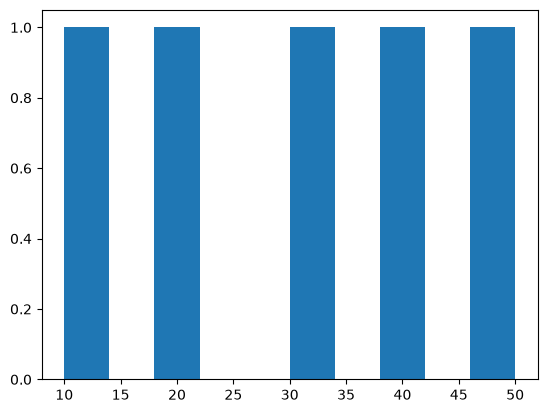

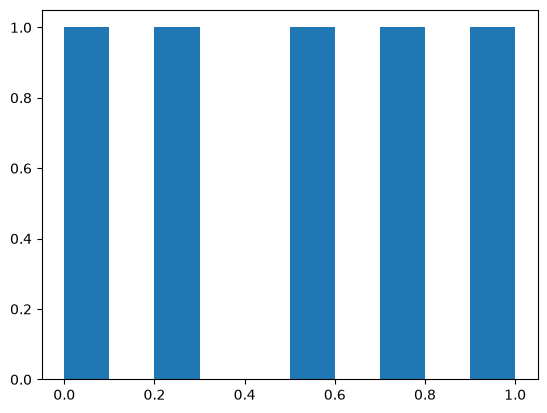

In [53]:
# Min Max Scaling:
data = [10, 20, 30, 40, 50]
plt.hist(data)
plt.show()
df = pd.DataFrame({"Data":data})
min_val =  df['Data'].min()
max_val =  df['Data'].max()
df['Data'] = (df['Data'] - min_val) / (max_val - min_val)
plt.hist(df['Data'])
plt.show()

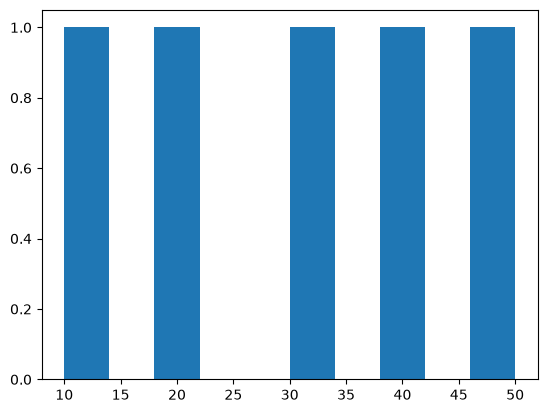

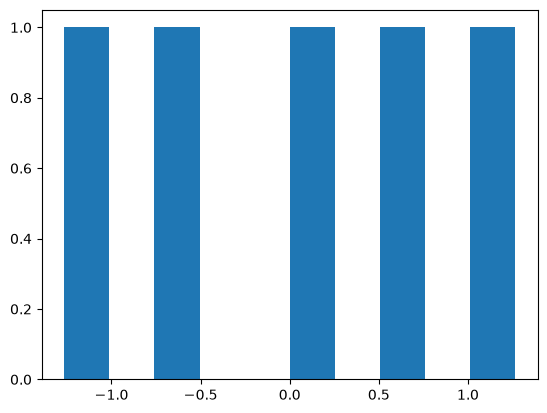

In [55]:
# Standardization : Z Score Transformation
data = [10, 20, 30, 40, 50]
df = pd.DataFrame({"Data":data})
plt.hist(df['Data'])
plt.show()
mean = df['Data'].mean()
std = df['Data'].std()
df['Data'] = (df['Data']-mean)/std
plt.hist(df['Data'])
plt.show()